## Step 1: Import the Dataset

Official RecipeNLG website: https://recipenlg.cs.put.poznan.pl/

In [30]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.__version__)

True
Tesla T4
2.10.0+cu128


In [31]:
import os
print(os.listdir("/kaggle/input/datasets/vaishnavil12/recipe-ngl"))

['full_dataset.csv']


In [32]:
import os
print(os.listdir("/kaggle/working/"))

['state.db', 'checkpoint_5000.pt', 'train.bin', 'train_loss.npy', 'val_loss.npy', 'best_model_params.pt', 'validation.bin', '.virtual_documents', 'test.bin']


In [33]:
import pandas as pd
import ast
import random

# ── Load CSV ──────────────────────────────────────────────────
CSV_PATH = "/kaggle/input/datasets/vaishnavil12/recipe-ngl/full_dataset.csv"

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} rows")

# ── Convert each row to flat text ────────────────────────────
def row_to_text(row):
    try:
        title       = str(row['title']).strip()
        ingredients = ast.literal_eval(row['ingredients'])
        directions  = ast.literal_eval(row['directions'])
        ing_text    = ", ".join([i.strip() for i in ingredients if i.strip()])
        dir_text    = "\n".join([f"{i+1}. {s.strip()}" for i, s in enumerate(directions) if s.strip()])
        return f"Recipe: {title}\nIngredients: {ing_text}\nInstructions:\n{dir_text}\n<|endofrecipe|>"
    except:
        return None

texts = [t for t in (row_to_text(r) for _, r in df.iterrows()) if t]
print(f"Valid recipes: {len(texts):,}")

# ── train-val-test split ─
random.seed(42)
random.shuffle(texts)

test_texts = texts[:5000]
val_texts = texts[5000:26000]
train_texts = texts[26000:]

ds = {
    "train": train_texts,
    "validation": val_texts,
    "test": test_texts
}

print(
    f"Train: {len(ds['train']):,} | "
    f"Val: {len(ds['validation']):,} | "
    f"Test: {len(ds['test']):,}"
)

Loaded 2,231,142 rows
Valid recipes: 2,231,142
Train: 2,205,142 | Val: 21,000 | Test: 5,000


In [34]:
import numpy as np

lengths = [len(t.split()) for t in texts]

print(f"Total recipes      : {len(lengths):,}")
print(f"Average length     : {np.mean(lengths):.2f} words")
print(f"Median length      : {np.median(lengths):.2f} words")
print(f"Max length         : {max(lengths):,} words")
print(f"% truncated at 128 : {np.mean(np.array(lengths)>128)*100:.1f}%")
print(f"% truncated at 256 : {np.mean(np.array(lengths)>256)*100:.1f}%")
print(f"% truncated at 512 : {np.mean(np.array(lengths)>512)*100:.1f}%")

Total recipes      : 2,231,142
Average length     : 141.39 words
Median length      : 113.00 words
Max length         : 3,028 words
% truncated at 128 : 41.5%
% truncated at 256 : 10.3%
% truncated at 512 : 0.9%


## Step 2: Tokenize the Dataset
(1) Tokenize the dataset into tokenIDs.

(2) Create a file called "train.bin" and "validtion.bin" and "test.bin" where we will store the tokenIDs from the entire dataset.

(3) We make sure the tokenIDs are stored on a disk, rather than on the RAM for efficient computations.

In [36]:
import tiktoken
import numpy as np
import os
from tqdm.auto import tqdm

enc = tiktoken.get_encoding("gpt2")

def tokenize_and_save(split_name, text_list):
    path = f"/kaggle/working/{split_name}.bin"
    if os.path.exists(path):
        print(f"{path} already exists, skipping.")
        return
    all_ids = [enc.encode_ordinary(t) for t in tqdm(text_list, desc=f"Tokenizing {split_name}")]
    total   = sum(len(x) for x in all_ids)
    arr     = np.memmap(path, dtype=np.uint16, mode='w+', shape=(total,))
    idx = 0
    for ids in all_ids:
        arr[idx:idx+len(ids)] = ids
        idx += len(ids)
    arr.flush()
    print(f"Saved {path}  ({os.path.getsize(path)/1e6:.1f} MB)")

tokenize_and_save('train',      ds['train'])
tokenize_and_save('validation', ds['validation'])
tokenize_and_save('test',       ds['test'])  

Tokenizing train:   0%|          | 0/2205142 [00:00<?, ?it/s]

Saved /kaggle/working/train.bin  (986.7 MB)


Tokenizing validation:   0%|          | 0/21000 [00:00<?, ?it/s]

Saved /kaggle/working/validation.bin  (9.5 MB)


Tokenizing test:   0%|          | 0/5000 [00:00<?, ?it/s]

Saved /kaggle/working/test.bin  (2.2 MB)


In [37]:
sample_token_lengths = [len(enc.encode_ordinary(t)) for t in texts]
print(f"Mean tokens/recipe     : {np.mean(sample_token_lengths):.0f} tokens")
print(f"Median tokens/recipe   : {np.median(sample_token_lengths):.2f} tokens")
print(f"% truncated at 128     : {np.mean(np.array(sample_token_lengths) > 128)*100:.1f}%")
print(f"% truncated at 256     : {np.mean(np.array(sample_token_lengths) > 256)*100:.1f}%")
print(f"% truncated at 512     : {np.mean(np.array(sample_token_lengths) > 512)*100:.1f}%")

Mean tokens/recipe     : 224 tokens
Median tokens/recipe   : 186.00 tokens
% truncated at 128     : 78.2%
% truncated at 256     : 28.2%
% truncated at 512     : 4.0%


In [39]:
import os

print(os.path.getsize("/kaggle/working/train.bin") % 2)
print(os.path.getsize("/kaggle/working/validation.bin") % 2)

0
0


## Step 3: Create Input-Output batches for the dataset

In [40]:
# Some functions from https://github.com/karpathy/nanoGPT/blob/master/train.py with slight modifications
#block size = context window
import torch
import numpy as np

def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap('/kaggle/working/train.bin', dtype=np.uint16, mode='r')
    else:
        data = np.memmap('/kaggle/working/validation.bin', dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y


## Step 4: Define the SLM Model Architecture

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx



In [5]:
config = GPTConfig(
    vocab_size=50257,     #  tokenizer's vocab size
    block_size=256,  # Context window; chosen after token-length analysis (128 truncated ~78% of recipes, 256 reduces truncation to ~28%)
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=True
)

model = GPT(config)

## Step 5: Define the loss function

In [43]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

## Step 6: Define SLM Training Configuration Part 1

In [44]:
# Training Config
import torch
from contextlib import nullcontext

learning_rate = 1e-4 #more stable training, earlier 1e-4
max_iters =  25000 
warmup_steps = 1000 #smoother initial train, earlier 100
min_lr = 1e-5 #lower rate, earlier 5e-4
eval_iters = 500 
batch_size = 32 # changed from 16, better gradient estimate
block_size = 256 #changed from 64, capture longer range dependencies

gradient_accumulation_steps = 32 # reduced from 50

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler

# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky
#dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

## Step 7: Define SLM Training Configuration Part 2

In [45]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR

##PUT IN WEIGHT DECAY, CHANGED BETA2 to 0.95
optimizer =  torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9) #weight decay for regularization

scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps) #Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) #Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

/tmp/ipykernel_58/2132813893.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


In [46]:
print(f"Starting LR: {optimizer.param_groups[0]['lr']}")
print(f"Scheduler last_epoch: {scheduler.last_epoch}")
print("Optimizer LR:", optimizer.param_groups[0]["lr"])
print("Scheduler LR:", scheduler.get_last_lr()[0])

Starting LR: 3.3333333333333335e-05
Scheduler last_epoch: 0
Optimizer LR: 3.3333333333333335e-05
Scheduler LR: 3.3333333333333335e-05


In [47]:
X, Y = get_batch("train")
logits, loss = model(X, Y)

print(logits.shape)
print(loss.item())

torch.Size([32, 256, 50257])
10.8992280960083


## Step 8: Pre-train the SLM

In [48]:
best_val_loss = float('inf')
best_model_params_path = "/kaggle/working/best_model_params.pt"
train_loss_list, validation_loss_list = [], []

# Ensure model is on the correct device
model = model.to(device)

# In your training loop
for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        # Ensure estimate_loss uses the correct device
        losses = estimate_loss(model)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.8f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)
        if epoch % 5000 == 0 and epoch != 0:
            torch.save(model.state_dict(),
                f"/kaggle/working/checkpoint_{epoch}.pt")
            print(f"Checkpoint saved at iter {epoch}")
        if epoch % 2000 == 0 and epoch != 0:
            np.save('/kaggle/working/train_loss.npy',
                np.array([x.cpu() if hasattr(x, 'cpu') else x for x in train_loss_list]))
            np.save('/kaggle/working/val_loss.npy',
                np.array([x.cpu() if hasattr(x, 'cpu') else x for x in validation_loss_list]))
            print("Loss lists saved")
            
    # Ensure X and y are on the correct device
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

  0%|          | 0/25000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 500: train loss 9.2697, val loss 9.2714
The current learning rate: 0.00006667
Epoch 1000: train loss 8.1064, val loss 8.1109
The current learning rate: 0.00010000
Epoch 1500: train loss 7.2529, val loss 7.2548
The current learning rate: 0.00009990
Epoch 2000: train loss 6.4809, val loss 6.4882
The current learning rate: 0.00009962
Loss lists saved
Epoch 2500: train loss 5.8528, val loss 5.8604
The current learning rate: 0.00009914
Epoch 3000: train loss 5.3910, val loss 5.3884
The current learning rate: 0.00009847
Epoch 3500: train loss 4.9748, val loss 4.9751
The current learning rate: 0.00009761
Epoch 4000: train loss 4.6548, val loss 4.6664
The current learning rate: 0.00009657
Loss lists saved
Epoch 4500: train loss 4.4132, val loss 4.4084
The current learning rate: 0.00009536
Epoch 5000: train loss 4.1878, val loss 4.2013
The current learning rate: 0.00009397
Checkpoint saved at iter 5000
Epoch 5500: train loss 4.0231, val loss 4.0338
The current learning rate: 0.00009242
Ep

In [49]:
# ✅ ADD — force save at end of training
torch.save(model.state_dict(), '/kaggle/working/checkpoint_final.pt')
np.save('/kaggle/working/train_loss.npy',np.array([x.cpu() if hasattr(x, 'cpu') else x for x in train_loss_list]))
np.save('/kaggle/working/val_loss.npy',np.array([x.cpu() if hasattr(x, 'cpu') else x for x in validation_loss_list]))
print("Training complete. All files saved.")

Training complete. All files saved.


## Step 9: Plot the SLM Loss Function

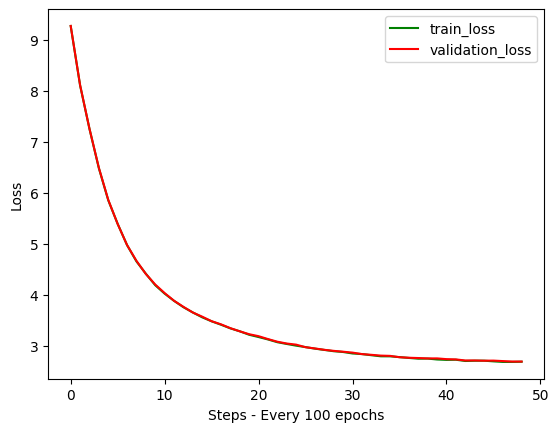

In [50]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r', label='validation_loss')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig('/kaggle/working/loss_plot.png', dpi=150)
plt.show()

## Step 10: Run SLM Inference on our trained model

In [6]:
#Load the model
model = GPT(config)  # re-create the model with same config
device =  "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "/kaggle/working/best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device))) # load best model states


<All keys matched successfully>

In [52]:
sentence = "Recipe: Chocolate Chip Cookies\nIngredients:"
context = torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(0)
y = model.generate(context, max_new_tokens=200, temperature=0.8, top_k=50)
print(enc.decode(y.squeeze().tolist()))

Recipe: Chocolate Chip Cookies
Ingredients: 2 c. shortening, 1 c. pecans, 1 c. sugar, 1 tsp. soda, 3 tsp. cinnamon, 2 c. baking powder, 2 c. flour, 1/4 c. chopped nuts, 2 eggs, 2 tsp. cinnamon, 1 tsp. soda, 2 tsp. salt, 1. baking soda, 3 c. vanilla extract, 1 c. peanut butter, 1 c. grated, 1 1 c. margarine, 3 c. brown sugar
Instructions:
1. Mix mixture, eggs, sugar, vanilla, and vanilla.
2. Beat in 9 x 13-inch dish.
3. Bake at 350° for 40 to 30 minutes.
4. Pour cream cheese batter into greased and cover pan.
5. Sprinkle remaining sugar over cake.
6. Bake at 350° for 30 minutes more.
<|endofrecipe|>Recipe: Sour Creamy Shrimp
Ingredients: 1


In [59]:
sentence = "Recipe: Chicken Soup\nIngredients:"
context = torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(0)
y = model.generate(context, max_new_tokens=200, temperature=0.8, top_k=50)
print(enc.decode(y.squeeze().tolist()))

Recipe: Chicken Soup
Ingredients: 1 cup yellow onion, 1, chopped, 1/3 cup green pepper, 1/4 cup minced garlic, 2 teaspoons crushed, 2 tablespoons ground cumin, 1/4 cup ground pepper, 1 12 teaspoons chopped fresh thyme, 1 cup dried basil, 1 cup celery, 2 cups finely diced onion, 3 Tablespoons ground cilantro, 1 teaspoon kosher salt, 3 tablespoons grated Parmesan, 1/4 teaspoon ground black pepper, 1 teaspoon salt, 3/2 cup chopped onions, 3/4 cup chopped garlic, 3 tablespoons cilantro, thawed, 1 tablespoon olive oil, 2 large tomatoes, 2 tablespoons fresh oregano, 2 cup extra-dried cabbage, minced, 2 tablespoons chopped green onions, minced, 1/4 cup chicken broth, 1/4 cups water, 3/4 cup beef broth, 1/2 teaspoon salt, 6 tablespoons mayonnaise, 1 tablespoon finely chopped fresh ground black pepper
Instructions:
1. Heat a


In [60]:
import numpy as np

train_loss = np.load('/kaggle/working/train_loss.npy')
val_loss   = np.load('/kaggle/working/val_loss.npy')

print(f"Total checkpoints recorded : {len(train_loss)}")
print(f"Approx last iteration      : {len(train_loss) * 500}")
print(f"First loss : {train_loss[0]:.4f}")
print(f"Last loss  : {train_loss[-1]:.4f}")
print(f"Best val loss : {min(val_loss):.4f}")

Total checkpoints recorded : 49
Approx last iteration      : 24500
First loss : 9.2697
Last loss  : 2.6882
Best val loss : 2.6917


In [61]:
# 1. Check the Training Configuration variables
print("--- Training Configuration ---")
config_vars = [
    'learning_rate', 'max_iters', 'batch_size', 'block_size', 
    'eval_iters', 'device', 'dtype', 'gradient_accumulation_steps'
]

for var in config_vars:
    if var in globals():
        print(f"{var: <28}: {globals()[var]}")
    else:
        print(f"{var: <28}: NOT DEFINED")

print("\n--- Model Architecture (GPTConfig) ---")
# 2. Check the actual config object assigned to the model
if 'model' in globals():
    c = model.config
    attrs = ['n_layer', 'n_head', 'n_embd', 'block_size', 'vocab_size', 'dropout']
    for attr in attrs:
        print(f"{attr: <28}: {getattr(c, attr)}")
    
    # Calculate total parameters
    model_params = sum(p.numel() for p in model.parameters())
    print(f"{'Total Parameters': <28}: {model_params / 1e6:.2f}M")
else:
    print("Model variable not found in memory.")

print("\n--- Optimizer State ---")
if 'optimizer' in globals():
    print(f"Optimizer LR: {optimizer.param_groups[0]['lr']}")
    print(f"Weight Decay: {optimizer.param_groups[0]['weight_decay']}")

--- Training Configuration ---
learning_rate               : 0.0001
max_iters                   : 25000
batch_size                  : 32
block_size                  : 256
eval_iters                  : 500
device                      : cuda
dtype                       : bfloat16
gradient_accumulation_steps : 32

--- Model Architecture (GPTConfig) ---
n_layer                     : 6
n_head                      : 6
n_embd                      : 384
block_size                  : 256
vocab_size                  : 50257
dropout                     : 0.1
Total Parameters            : 30.04M

--- Optimizer State ---
Optimizer LR: 1e-05
Weight Decay: 0.1


In [53]:
import numpy as np
import torch

def get_batch_test():
    data = np.memmap('/kaggle/working/test.bin',
                     dtype=np.uint16,
                     mode='r')

    ix = torch.randint(len(data) - block_size, (batch_size,))

    x = torch.stack([
        torch.from_numpy((data[i:i+block_size]).astype(np.int64))
        for i in ix
    ])

    y = torch.stack([
        torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64))
        for i in ix
    ])

    return x.to(device), y.to(device)

In [54]:
import numpy as np

@torch.no_grad()
def evaluate_test(eval_iters=500):

    model.eval()

    losses = []

    for _ in range(eval_iters):

        X, Y = get_batch_test()

        with ctx:
            _, loss = model(X, Y)

        losses.append(loss.item())

    return np.mean(losses)

In [55]:
test_loss = evaluate_test()

print(f"Test Loss : {test_loss:.4f}")

Test Loss : 2.6767


In [56]:
import math

perplexity = math.exp(test_loss)

print(f"Perplexity : {perplexity:.2f}")

Perplexity : 14.54


In [57]:
!pip install nltk

In [58]:
from nltk.translate.bleu_score import sentence_bleu
bleu_scores = []

for ref in test_texts[:100]:

    prompt = ref.split("Instructions:")[0]

    context = torch.tensor(
        enc.encode_ordinary(prompt)
    ).unsqueeze(0).to(device)

    output = model.generate(
        context,
        max_new_tokens=200,
        temperature=0.8,
        top_k=50
    )

    pred = enc.decode(output.squeeze().tolist())

    score = sentence_bleu(
        [ref.split()],
        pred.split()
    )

    bleu_scores.append(score)

print("Average BLEU:", np.mean(bleu_scores))

Average BLEU: 0.27473812480449833


In [7]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 30,044,544
Trainable Parameters : 30,044,544
